In [9]:
import json
from pathlib import Path

# ─── CONFIG ──────────────────────────────────────────────
data_root    = Path("/Volumes/2tb_western/ghgsat data")    # ◀ change to your GHGSat root
output_json  = Path("complete_observations_with_csv.json")
required     = ["CH4","CH4PL","CH4ER","ALB","FLG"]        # your five TIFF layers
csv_suffix   = "_CH4SR.csv"                              # your CSV suffix
# ─────────────────────────────────────────────────────────

observations = {}

for meta_path in data_root.rglob("*.json"):
    # skip any JSON that isn't a metadata file
    meta = json.loads(meta_path.read_text())
    if "metadata_version" not in meta or "layers" not in meta:
        continue

    cap_dir = meta_path.parent
    # pull date & IDs from folder hierarchy: …/<YYYY>/<MM>/<DD>/<SAT>/<CAP>/
    parts = cap_dir.parts
    # find a 4-digit year
    for i, p in enumerate(parts):
        if p.isdigit() and len(p)==4:
            try:
                year,month,day = parts[i:i+3]
                sat,cap = parts[i+3:i+5]
            except ValueError:
                continue
            key = f"{year}-{month}-{day}_{sat}_{cap}"
            break
    else:
        continue

    entry = {}
    ok = True
    # check TIFF layers
    for lyr in required:
        fn = next((L["filename"] for L in meta["layers"]
                   if L["filename"].upper().endswith(f"_{lyr}.TIF")), None)
        if not fn:
            ok = False; break
        path = cap_dir / fn
        if not path.is_file():
            ok = False; break
        entry[lyr] = str(path)
    if not ok:
        continue

    # check CSV
    fn_csv = next((F["filename"] for F in meta.get("files",[])
                   if F["filename"].upper().endswith(csv_suffix.upper())), None)
    if not fn_csv:
        continue
    csv_path = cap_dir / fn_csv
    if not csv_path.is_file():
        continue

    entry["CH4SR"] = str(csv_path)
    observations[key] = entry

# write out only the fully-complete captures
output_json.write_text(json.dumps(observations, indent=2))
print(f"✅ Found {len(observations)} complete captures. Wrote → {output_json}")


✅ Found 119 complete captures. Wrote → complete_observations_with_csv.json


In [16]:
# build_multiple_npy_by_resampling.py

"""
This script reads your `complete_observations_with_csv.json` (with CH4, CH4PL, CH4ER, ALB, FLG paths),
applies four different resize methods to each TIFF layer, and saves a separate `.npy` file for each method.

Output files:
  - ghgsat_data_nearest.npy
  - ghgsat_data_bilinear.npy
  - ghgsat_data_bicubic.npy
  - ghgsat_data_lanczos.npy

Usage:
  python build_multiple_npy_by_resampling.py
"""

import json
from pathlib import Path
import numpy as np
import rasterio
from PIL import Image

# ─── CONFIG ──────────────────────────────────────────────────────────
json_path    = Path("complete_observations_with_csv.json")
layer_order  = ["CH4", "CH4PL", "CH4ER", "ALB", "FLG"]
target_size  = (128, 128)  # (width, height)
methods = {
    "nearest": Image.Resampling.NEAREST,
    "bilinear": Image.Resampling.BILINEAR,
    "bicubic": Image.Resampling.BICUBIC,
    "lanczos": Image.Resampling.LANCZOS
}
# ──────────────────────────────────────────────────────────────────────

# Load JSON summary
data = json.loads(json_path.read_text())
keys = list(data.keys())
if not keys:
    raise RuntimeError(f"No captures found in {json_path}")

N = len(keys)
C = len(layer_order)
H, W = target_size[1], target_size[0]

# For each resampling method, build and save .npy
for name, resample in methods.items():
    print(f"Building dataset with {name} resampling...")
    arr = np.empty((N, H, W, C), dtype=np.float32)
    for i, key in enumerate(keys):
        for j, lyr in enumerate(layer_order):
            path = Path(data[key][lyr])
            with rasterio.open(path) as src:
                img = src.read(1)
            img_resized = np.array(Image.fromarray(img).resize(target_size, resample=resample))
            arr[i, :, :, j] = img_resized
    out_file = f"ghgsat_data_{name}.npy"
    np.save(out_file, arr)
    print(f"  Saved shape {arr.shape} → {out_file}")

print("✅ All datasets built.")


Building dataset with nearest resampling...
  Saved shape (119, 128, 128, 5) → ghgsat_data_nearest.npy
Building dataset with bilinear resampling...
  Saved shape (119, 128, 128, 5) → ghgsat_data_bilinear.npy
Building dataset with bicubic resampling...
  Saved shape (119, 128, 128, 5) → ghgsat_data_bicubic.npy
Building dataset with lanczos resampling...
  Saved shape (119, 128, 128, 5) → ghgsat_data_lanczos.npy
✅ All datasets built.


Comparing compression methods for capture: 2024-04-03_C7_C7_24020884_20240403_20240410_Sj7BkjW


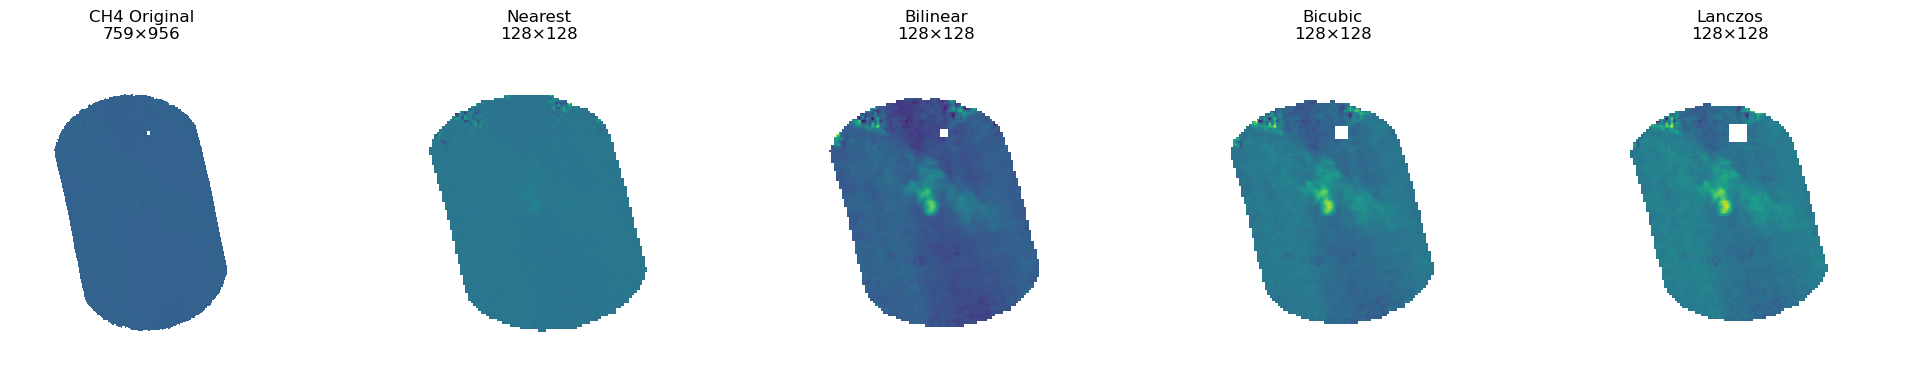

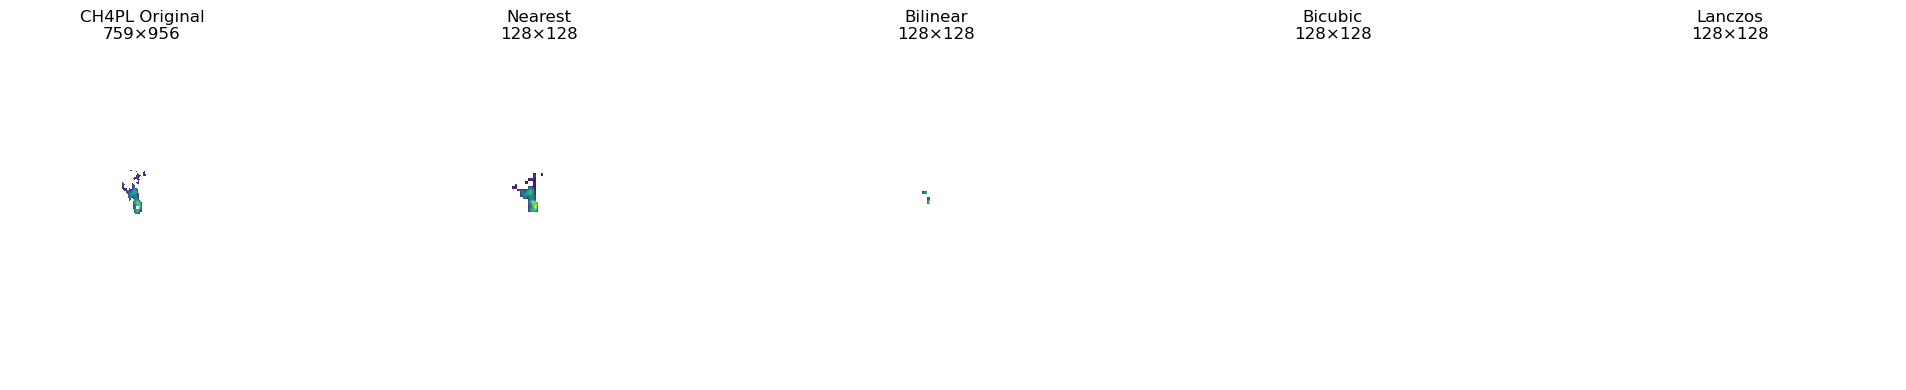

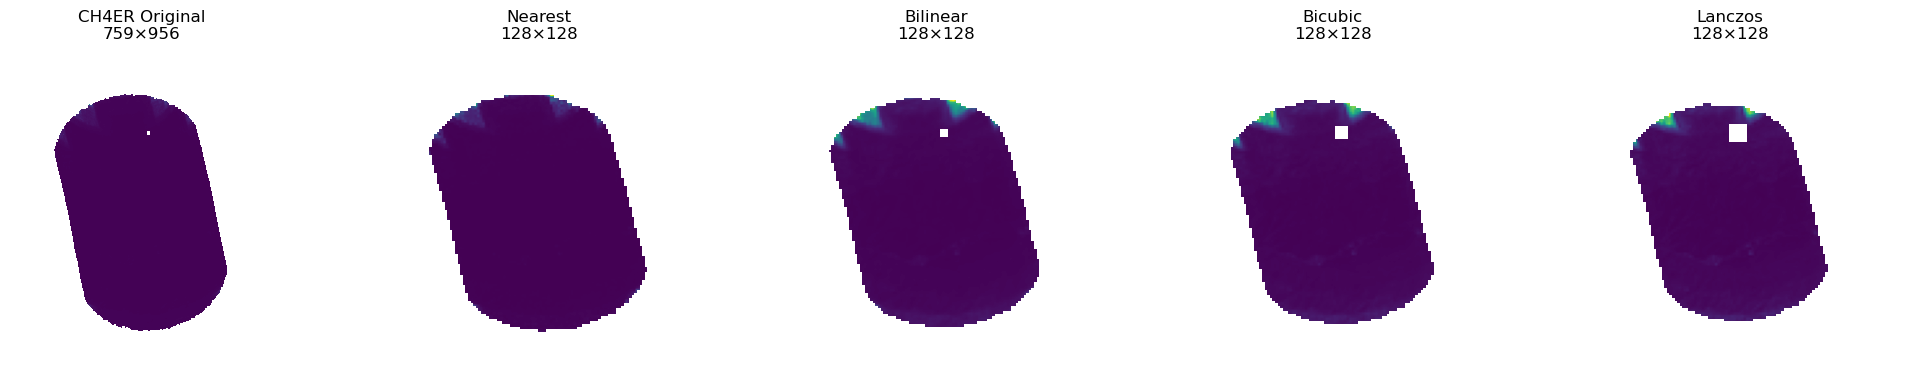

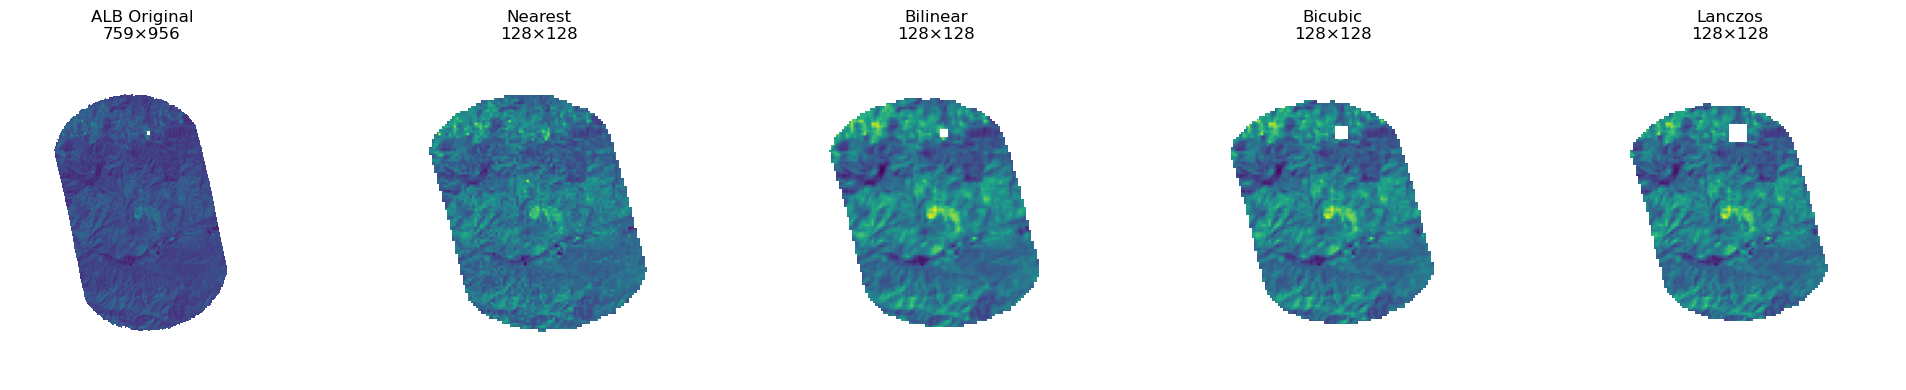

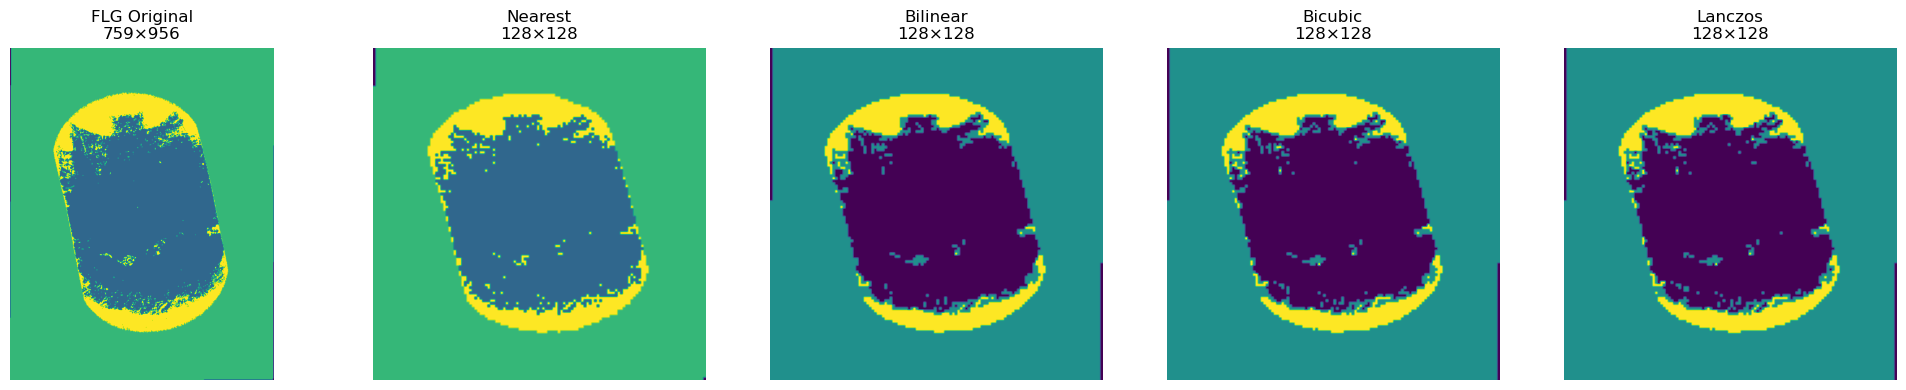

In [15]:
import json
from pathlib import Path
import rasterio
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# ─── CONFIG ──────────────────────────────────────────────
json_path    = Path("complete_observations_with_csv.json")  # Metadata JSON
layer_order  = ["CH4", "CH4PL", "CH4ER", "ALB", "FLG"]       # Layers to test
target_size  = (128, 128)                                   # (width, height)
methods      = {
    "Nearest": Image.Resampling.NEAREST,
    "Bilinear": Image.Resampling.BILINEAR,
    "Bicubic": Image.Resampling.BICUBIC,
    "Lanczos": Image.Resampling.LANCZOS
}
cmap = "viridis"  # Color map for display
# ─────────────────────────────────────────────────────────

# Load JSON summary
data = json.loads(json_path.read_text())
if not data:
    raise RuntimeError(f"No captures found in {json_path}")

# Use the first capture for demonstration
first_key = next(iter(data))
print(f"Comparing compression methods for capture: {first_key}")

# Loop through each layer
for lyr in layer_order:
    path = Path(data[first_key][lyr])

    # Read original
    with rasterio.open(path) as src:
        orig = src.read(1)

    # Resize with each method
    resized_images = {
        name: np.array(Image.fromarray(orig).resize(target_size, resample=method))
        for name, method in methods.items()
    }

    # Plot original + each resized variant in color
    fig, axes = plt.subplots(1, 1 + len(methods), figsize=(4 * (1 + len(methods)), 4))
    axes[0].imshow(orig, cmap=cmap)
    axes[0].set_title(f"{lyr} Original\n{orig.shape[1]}×{orig.shape[0]}")
    axes[0].axis("off")

    for i, (name, img) in enumerate(resized_images.items(), start=1):
        axes[i].imshow(img, cmap=cmap)
        axes[i].set_title(f"{name}\n{target_size[0]}×{target_size[1]}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()


In [17]:
import numpy as np
from pathlib import Path

def sizeof_fmt(num, suffix='B'):
    """Human-readable file size."""
    for unit in ['','K','M','G','T','P','E','Z']:
        if abs(num) < 1024.0:
            return f"{num:3.1f}{unit}{suffix}"
        num /= 1024.0
    return f"{num:.1f}Y{suffix}"

# Directory containing the .npy files
npy_dir = Path(".")

# Pattern to match your datasets
npy_files = list(npy_dir.glob("ghgsat_data_*.npy"))

if not npy_files:
    print("No .npy files matching 'ghgsat_data_*.npy' found in the current directory.")
else:
    print(f"Found {len(npy_files)} .npy dataset(s):\n")
    for npy_file in npy_files:
        # Get file size on disk
        size = sizeof_fmt(npy_file.stat().st_size)
        # Load metadata only to get shape and dtype
        arr = np.load(npy_file, mmap_mode='r')
        shape = arr.shape
        dtype = arr.dtype
        print(f"{npy_file.name}")
        print(f"  - Shape: {shape}")
        print(f"  - Data type: {dtype}")
        print(f"  - File size: {size}\n")

Found 4 .npy dataset(s):

ghgsat_data_nearest.npy
  - Shape: (119, 128, 128, 5)
  - Data type: float32
  - File size: 37.2MB

ghgsat_data_bicubic.npy
  - Shape: (119, 128, 128, 5)
  - Data type: float32
  - File size: 37.2MB

ghgsat_data_bilinear.npy
  - Shape: (119, 128, 128, 5)
  - Data type: float32
  - File size: 37.2MB

ghgsat_data_lanczos.npy
  - Shape: (119, 128, 128, 5)
  - Data type: float32
  - File size: 37.2MB

